In [7]:
import matplotlib.pyplot as plt
import pandas as pd

from tqdm import tqdm

In [2]:
df = pd.read_parquet("data/ivdata.parquet")
df.head()

,Date,Expiry,Texp,z,w,DTE,Group
index,,,,,,,
219043,2000-01-03,2000-01-22,0.052019,-0.400915,NaN,19,1m
219044,2000-01-03,2000-01-22,0.052019,-0.350905,0.000097,19,1m
219045,2000-01-03,2000-01-22,0.052019,-0.326807,0.000086,19,1m
219046,2000-01-03,2000-01-22,0.052019,-0.303277,0.000076,19,1m
219047,2000-01-03,2000-01-22,0.052019,-0.280287,0.000066,19,1m


In [6]:
S, R = [], []
for _, group in tqdm(df.groupby(["Date", "Texp"])):
    s = group["z"].min()
    r = group["z"].max() - s

    S.append(s)
    R.append(r)

100%|██████████| 91563/91563 [00:17<00:00, 5383.70it/s]


Text(0, 0.5, 'support range')

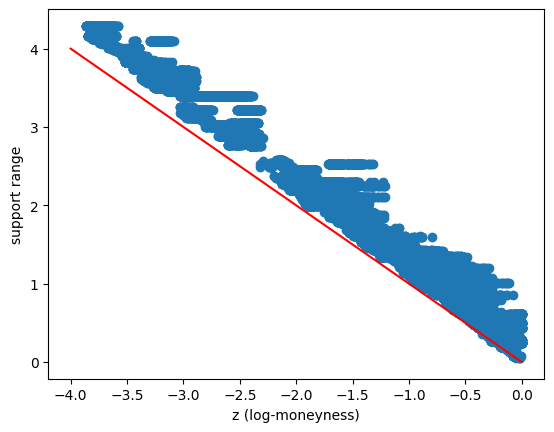

In [11]:
plt.scatter(S, R)
plt.plot([-4, 0], [4, 0], color="r")
plt.xlabel("z (log-moneyness)")
plt.ylabel("support range")